# Second experiment: Hierarchical model

Preparation of a model with a hierarchical structure in which the pigment or dye substrate is separated first by a binarization with reflectance dataset https://github.com/colorimgugr/HyperDocApp . Then, the binder is classified, and finally, the material is identified. This approach makes it possible to assess whether model performance improves compared to a direct multiclass classification. Only SVM classifier will be used since is the better classifier as it is shown in the first experiment.

## Import all libraries use

In [1]:
import pandas as pd
import numpy as np
from scipy.io import loadmat
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

## Import dataset

In [2]:
def load_data():
    data = loadmat('dataset_without_substrate.mat')

    X_train = data['X_train']
    y_train = data['y_train'].ravel()

    X_test = data['X_test']
    y_test = data['y_test'].ravel()

    return X_train, y_train, X_test, y_test

#X variables are the pixels and Y variables are the labels
X_train, y_train, X_test, y_test = load_data()

print("Train X:", X_train.shape)
print("Train y:", y_train.shape)

print("Test X:", X_test.shape)
print("Test y:", y_test.shape)

Train X: (39507, 121)
Train y: (39507,)
Test X: (9809, 121)
Test y: (9809,)


In [3]:
df_train = pd.DataFrame(X_train)
df_train["label"] = y_train

print("Primeras filas del DataFrame:")
print(df_train.head())

Primeras filas del DataFrame:
            0           1           2           3           4           5  \
0  160.947632  228.826462  285.927002  344.375916  407.790649  445.744476   
1  158.270508  217.518707  277.381256  333.499512  379.157928  446.760040   
2  148.375381  208.553558  262.519989  322.142334  377.076996  419.701782   
3  154.939667  209.060791  268.925537  327.528839  382.526001  427.550720   
4  156.129364  223.788437  290.352386  355.954529  421.231262  474.442505   

            6           7           8           9  ...       112       113  \
0  487.153442  512.006592  525.024109  530.862305  ...  0.026589  0.039122   
1  474.445343  501.509827  519.333130  523.176147  ...  0.000000  0.000000   
2  452.303223  485.511139  515.942932  520.926270  ...  0.000000  0.000000   
3  466.162964  497.501221  517.793091  533.608032  ...  0.000000  0.000000   
4  517.736267  551.741455  580.682800  585.867310  ...  0.000000  0.000000   

   114  115  116  117       118       

In [4]:
print("Distribución de clases:")
print(df_train["label"].value_counts())

Distribución de clases:
label
109    5104
62     4788
85     4724
63     4682
64     4596
65     4577
88     4221
87     3661
117    3154
Name: count, dtype: int64


In [5]:
df_test = pd.DataFrame(X_test)
df_test["label"] = y_test

print("Primeras filas del DataFrame de TEST:")
print(df_test.head())

Primeras filas del DataFrame de TEST:
            0           1           2           3           4           5  \
0  213.805298  299.587830  386.809052  463.727539  526.957031  590.018799   
1  214.336914  282.420776  371.378326  447.243835  513.097290  570.108459   
2  214.160767  296.567749  379.936768  461.647888  524.024353  589.989563   
3  212.476517  296.685669  378.694519  446.897705  506.033630  565.616455   
4  206.896057  284.726196  366.295471  440.804932  521.065735  575.750610   

            6           7           8           9  ...  112       113  \
0  641.859497  681.637085  713.094971  732.311340  ...  0.0  0.000000   
1  627.410828  663.361816  684.788574  712.604126  ...  0.0  0.000000   
2  637.650024  676.242798  720.215210  737.161499  ...  0.0  0.000000   
3  619.541138  659.694458  687.221985  703.870178  ...  0.0  0.000000   
4  628.961731  665.132935  691.816772  719.000122  ...  0.0  0.088544   

        114  115  116  117  118       119       120  label  

In [6]:
print("Distribución de clases:")
print(df_test["label"].value_counts())

Distribución de clases:
label
88     2975
109    2094
87     1001
62      856
63      803
64      792
117     590
65      364
85      334
Name: count, dtype: int64


In [7]:
class_names = {
    62: "Esmalte-GA",
    63: "Lapislázuli-GA",
    64: "BlancoPb-GA",
    65: "Calcita-GA",
    85: "Esmalte-CH",
    87: "BlancoPb-CH",
    88: "Calcita-CH",
    109: "Imperial Yellow Ink-GA",
    117: "Azafrán-GA",
}

## Generation of new labels to include binders

In [8]:
def obtener_aglutinante(label):
    nombre = class_names[label]

    if nombre.endswith("-GA"):
        return 0   # goma arábiga
    elif nombre.endswith("-CH"):
        return 1   # clara de huevo
    else:
        raise ValueError(f"La clase {label} no termina en -GA ni en -CH")

In [9]:
y_train_aglutinante = np.array([obtener_aglutinante(label) for label in y_train])
y_test_aglutinante = np.array([obtener_aglutinante(label) for label in y_test])
print("Train aglutinante:", np.unique(y_train_aglutinante, return_counts=True))
print("Test aglutinante:", np.unique(y_test_aglutinante, return_counts=True))

Train aglutinante: (array([0, 1]), array([26901, 12606]))
Test aglutinante: (array([0, 1]), array([5499, 4310]))


In [10]:
binder_names = {0: "Goma Arábiga", 1: "Clara de Huevo"}

unique, counts = np.unique(y_train_aglutinante, return_counts=True)
for u, c in zip(unique, counts):
    print(binder_names[u], c)

Goma Arábiga 26901
Clara de Huevo 12606


## SVM hierarchical classification

### Level 1: Classification of binders

In [11]:
svm_lvl1 = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', C=10, gamma='scale', class_weight='balanced'))
])
svm_lvl1.fit(X_train, y_train_aglutinante)
y_pred_lvl1 = svm_lvl1.predict(X_test)

In [12]:
print("Accuracy:", accuracy_score(y_test_aglutinante, y_pred_lvl1))
print(classification_report(
    y_test_aglutinante,
    y_pred_lvl1,
    target_names=["GA", "CH"]
))

Accuracy: 0.8541135691711693
              precision    recall  f1-score   support

          GA       0.79      1.00      0.88      5499
          CH       1.00      0.67      0.80      4310

    accuracy                           0.85      9809
   macro avg       0.90      0.83      0.84      9809
weighted avg       0.88      0.85      0.85      9809



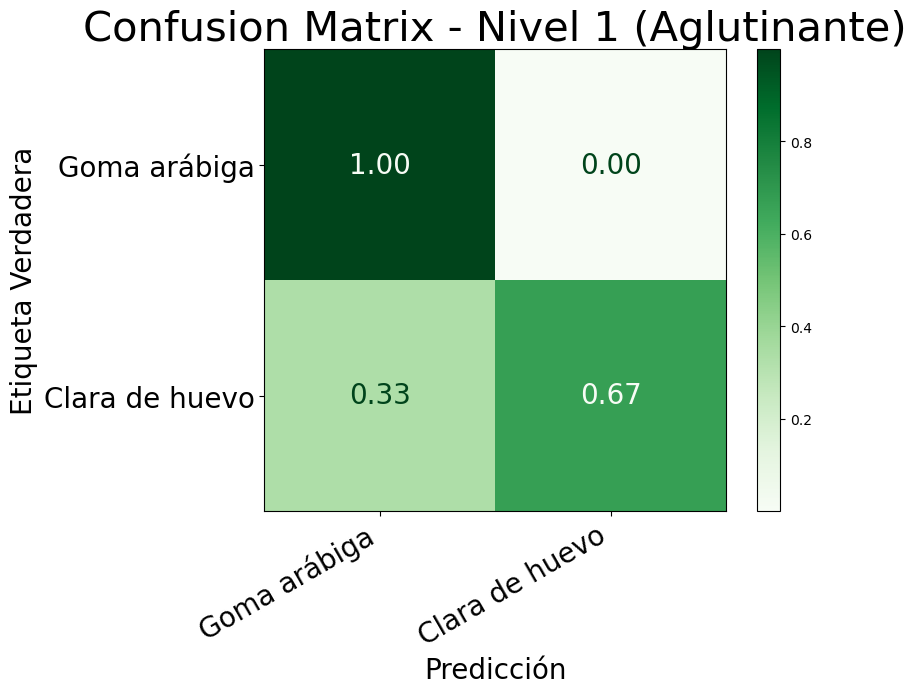

In [13]:
display_labels = ["Goma arábiga", "Clara de huevo"]

fig, ax = plt.subplots(figsize=(8,6))

disp = ConfusionMatrixDisplay.from_predictions(
    y_test_aglutinante,
    y_pred_lvl1,
    normalize="true",
    values_format=".2f",
    cmap="Greens",
    ax=ax
)

plt.title("Confusion Matrix - Nivel 1 (Aglutinante)", fontsize=30)

# tamaño del texto dentro de las celdas
for text in ax.texts:
    text.set_fontsize(20)

ax.set_xticklabels(display_labels, rotation=30, ha="right", fontsize=20)
ax.set_yticklabels(display_labels, rotation=0, fontsize=20)

ax.set_xlabel("Predicción", fontsize=20)
ax.set_ylabel("Etiqueta Verdadera", fontsize=20)

plt.show()

### Level 2: Material classification

In [14]:
# we separate the pigments and dyes in two subset divided by the binder
ga_labels = [62, 63, 64, 65, 109, 117]
ch_labels = [85, 87, 88]

mask_train_ga = np.isin(y_train, ga_labels)
mask_train_ch = np.isin(y_train, ch_labels)

mask_test_ga = np.isin(y_test, ga_labels)
mask_test_ch = np.isin(y_test, ch_labels)

X_train_ga = X_train[mask_train_ga]
y_train_ga = y_train[mask_train_ga]

X_train_ch = X_train[mask_train_ch]
y_train_ch = y_train[mask_train_ch]

X_test_ga = X_test[mask_test_ga]
y_test_ga = y_test[mask_test_ga]

X_test_ch = X_test[mask_test_ch]
y_test_ch = y_test[mask_test_ch]

In [15]:
# GA
svm_ga = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', C=10, gamma='scale'))
])

svm_ga.fit(X_train_ga, y_train_ga)

# CH
svm_ch = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', C=10, gamma='scale'))
])

svm_ch.fit(X_train_ch, y_train_ch)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('svm', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'


### Final Classification: The hierarchical model

In [16]:
y_pred_final = []

for x in X_test:
    x = x.reshape(1, -1)
    
    # Nivel 1
    pred_binder = svm_lvl1.predict(x)[0]
    
    # Nivel 2
    if pred_binder == 0:  # GA
        pred = svm_ga.predict(x)[0]
    else:  # CH
        pred = svm_ch.predict(x)[0]
    
    y_pred_final.append(pred)

y_pred_final = np.array(y_pred_final)

In [17]:
print("Accuracy final:", accuracy_score(y_test, y_pred_final))

print(classification_report(
    y_test,
    y_pred_final,
    target_names=[class_names[l] for l in sorted(class_names.keys())]
))

Accuracy final: 0.7878478947904985
                        precision    recall  f1-score   support

            Esmalte-GA       0.99      0.97      0.98       856
        Lapislázuli-GA       0.74      0.76      0.75       803
           BlancoPb-GA       0.67      0.93      0.78       792
            Calcita-GA       0.79      0.99      0.88       364
            Esmalte-CH       0.88      0.99      0.93       334
           BlancoPb-CH       0.95      0.77      0.85      1001
            Calcita-CH       1.00      0.57      0.73      2975
Imperial Yellow Ink-GA       0.68      0.87      0.76      2094
            Azafrán-GA       0.55      0.96      0.70       590

              accuracy                           0.79      9809
             macro avg       0.80      0.87      0.82      9809
          weighted avg       0.84      0.79      0.79      9809



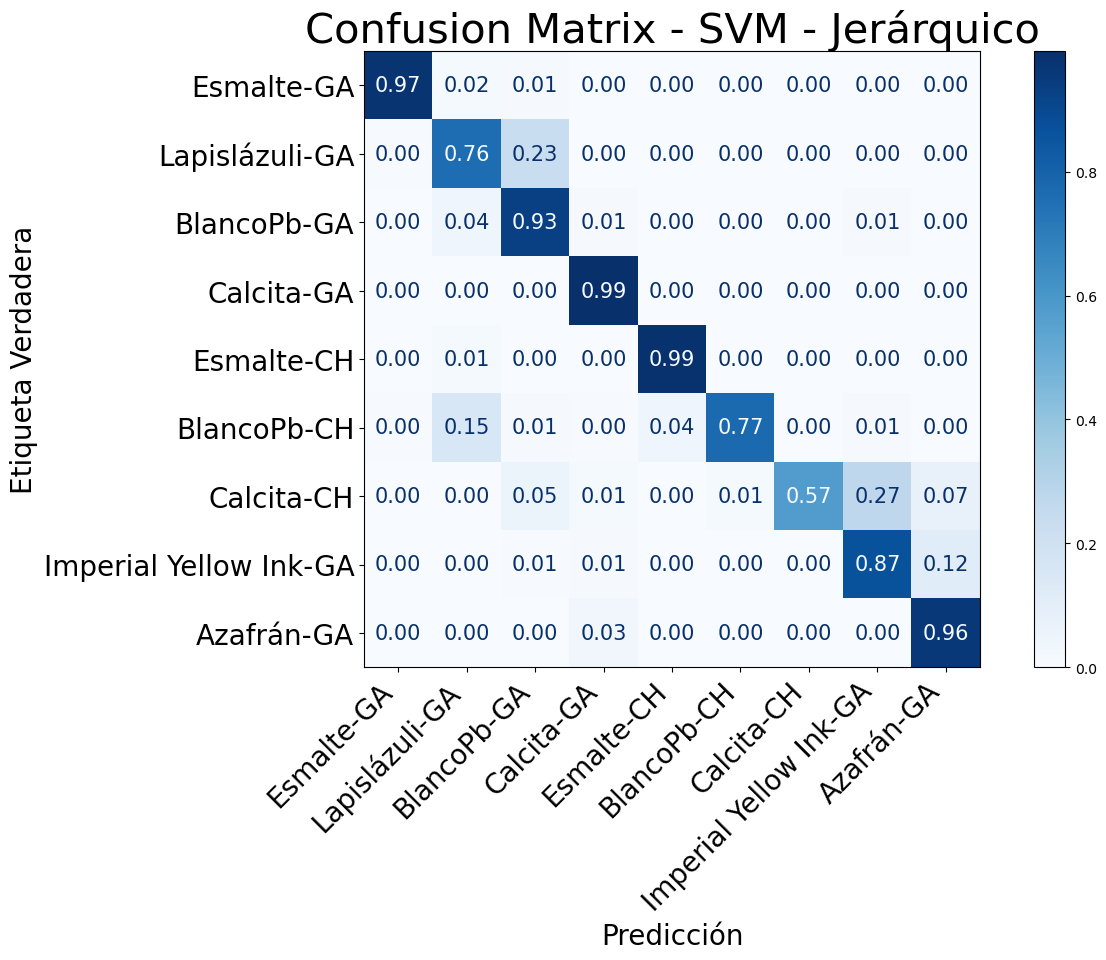

In [18]:
labels = np.unique(y_test)
display_labels = [class_names[l] for l in labels]

fig, ax = plt.subplots(figsize=(14,8))

disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_final,  
    labels=labels,
    normalize="true",
    values_format=".2f",
    cmap="Blues",
    ax=ax
)

plt.title("Confusion Matrix - SVM - Jerárquico", fontsize=30)

for text in ax.texts:
    text.set_fontsize(15)

ax.set_xticklabels(display_labels, rotation=45, ha="right", fontsize=20)
ax.set_yticklabels(display_labels, rotation=0, fontsize=20)

ax.set_xlabel("Predicción", fontsize=20)
ax.set_ylabel("Etiqueta Verdadera", fontsize=20)

plt.show()

## Comparison with a multiclass classifier with binarization done

In [19]:
svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=10, gamma="scale"))
])
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

In [20]:
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nClassification report:")
print(classification_report(y_test, y_pred_svm))

Accuracy: 0.7924355184014681

Classification report:
              precision    recall  f1-score   support

          62       0.99      0.97      0.98       856
          63       0.60      0.75      0.67       803
          64       0.69      0.94      0.79       792
          65       0.78      1.00      0.88       364
          85       0.97      0.99      0.98       334
          87       0.99      0.63      0.77      1001
          88       1.00      0.64      0.78      2975
         109       0.75      0.86      0.80      2094
         117       0.50      0.97      0.66       590

    accuracy                           0.79      9809
   macro avg       0.81      0.86      0.81      9809
weighted avg       0.85      0.79      0.80      9809



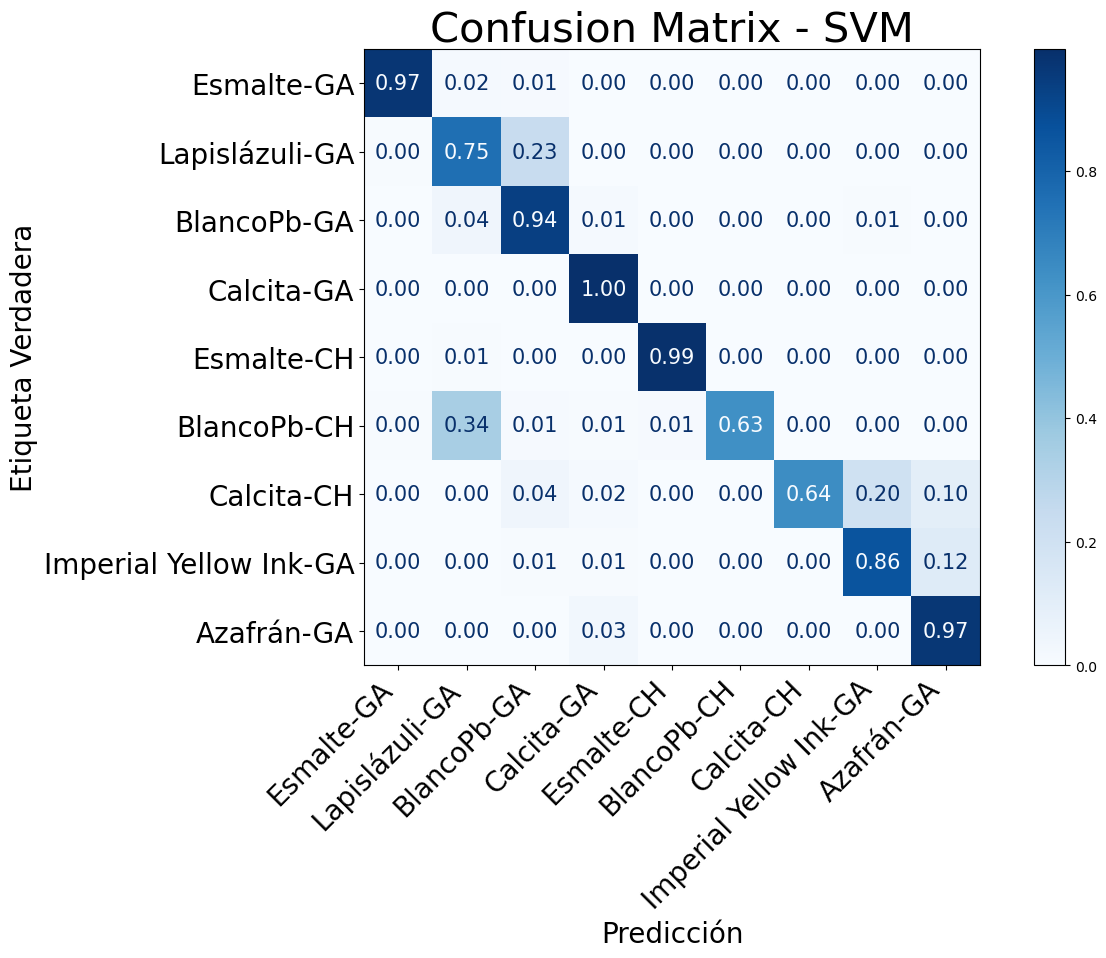

In [21]:
labels = np.unique(y_test)
display_labels = [class_names[l] for l in labels]

fig, ax = plt.subplots(figsize=(14,8))

disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_svm,
    normalize="true",
    values_format=".2f",
    cmap="Blues",
    ax=ax
)

plt.title("Confusion Matrix - SVM", fontsize=30)

for text in ax.texts:
    text.set_fontsize(15)

ax.set_xticklabels(display_labels, rotation=45, ha="right", fontsize=20)
ax.set_yticklabels(display_labels, rotation=0, fontsize=20)

ax.set_xlabel("Predicción", fontsize=20)
ax.set_ylabel("Etiqueta Verdadera", fontsize=20)

plt.show()